In [17]:
from symfit import parameters, variables, sin, cos, Fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
df3= pd.read_csv('freq_x_rot.csv', header = 0)

x = df3['angle']
x = x*np.pi/180.
y_sx = df3['fre_sum']/1E3
y_dx = df3['freq_diff']/1E6
y_1Dx = df3['freq_1D']/1E6 #freq of |1> -> |0>
y_2Dx = df3['freq_2D']/1E6 #freq of |0> -> |-1>

In [19]:

y_float = np.array(y_sx, dtype=float)
x_float = np.array(x, dtype = float)
# x= np.asarray(x)
# y_sx=np.asarray(y_sx)
# type(x)

In [20]:
type(x_float)

numpy.ndarray

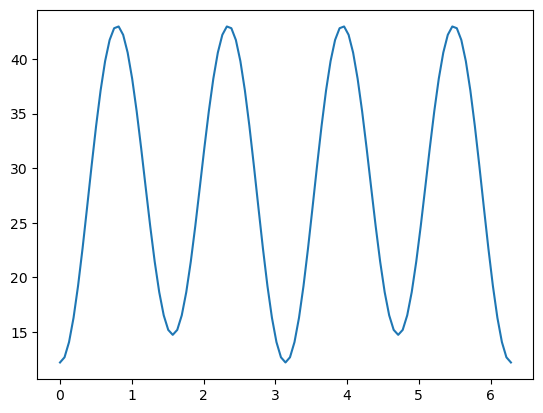

In [21]:
plt.plot(x_float, y_float)

In [22]:
# #fitting functions
# def Hcsa1(theta,A1, B1, C1):
    
#     freq_csa1 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180)
#     return freq_csa1

# def HQ2 (theta,A1, B1, C1, D1, E1):
#     freq_Q2 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180) + D1*np.cos(4*theta*np.pi/180) + E1*np.sin(4*theta*np.pi/180) 
#     return freq_Q2

In [51]:

def fourier_series(x, f, n=0):
    """
    Returns a symbolic fourier series of order `n`.

    :param n: Order of the fourier series.
    :param x: Independent variable
    :param f: Frequency of the fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * f * x ) + bi * sin(i * f * x )
                     for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series

x, y = variables('x, y')
w, = parameters('w')
model_dict = {y: fourier_series(x, f=w, n=2)}


In [24]:
print(model_dict)

{y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + a3*cos(3*w*x) + b1*sin(w*x) + b2*sin(2*w*x) + b3*sin(3*w*x)}


Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.824642e+01 2.851711e-14
a1        -1.264300e+00 4.219839e-14
a2        -1.475996e+01 3.921773e-14
b1        -1.013931e-13 3.967097e-14
b2        2.287878e-13 8.517701e-14
w         2.000000e+00 8.135025e-16
Status message         Optimization terminated successfully.
Number of iterations   27
Objective              <symfit.core.objectives.LeastSquares object at 0x7f6b986c66b0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f6b9876bd90>

Goodness of fit qualifiers:
chi_squared            7.42589164420006e-24
objective_value        3.71294582210003e-24
r_squared              1.0


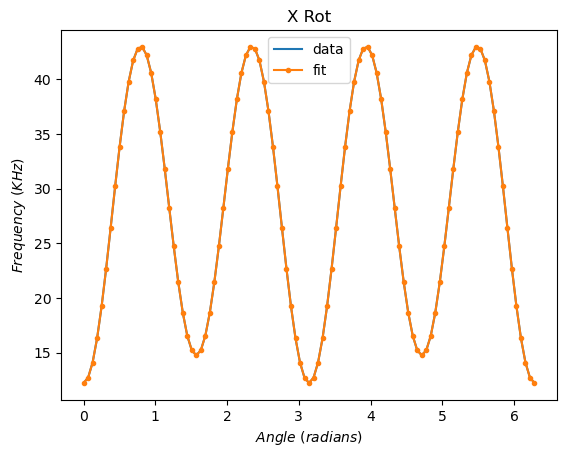

In [59]:
# Reading Data
# xdata = np.linspace(-np.pi, np.pi)
# ydata = np.zeros_like(xdata)
# ydata[xdata > 0] = 1

xdata = x_float
ydata = y_float

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker=".", label = "fit")
plt.title('X Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

In [29]:
print(fit_result.params)
type(fit_result.params)

OrderedDict([('a0', 28.246416757877657), ('a1', -1.2643001806268763), ('a2', -14.759960430984489), ('a3', 4.757577474241789e-13), ('b1', 5.592728444439744e-13), ('b2', 3.1956859362976095e-15), ('b3', -8.020800626129536e-15), ('w', 2.0000000000000004)])


collections.OrderedDict

In [33]:
df3= pd.read_csv('freq_y_rot.csv', header = 0)

x = df3['angle']
x = x*np.pi/180
f_sy = df3['fre_sum']/1E3
f_dxy= df3['freq_diff']/1E6
f_1Dy = df3['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dy = df3['freq_2D']/1E6 #freq of |0> -> |-1>

In [36]:
fy_float = np.array(f_sy, dtype=float)
x_float = np.array(x, dtype = float)

In [45]:
def fourier_series(x, f, n=0):
    """
    Returns a symbolic fourier series of order `n`.

    :param n: Order of the fourier series.
    :param x: Independent variable
    :param f: Frequency of the fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * f * x ) + bi * sin(i * f * x )
                     for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series

x, y = variables('x, y')
w, = parameters('w')
model_dict = {y: fourier_series(x, f=w, n=2)}


Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        3.245884e+01 2.202122e-14
a1        -1.217312e+01 3.079824e-14
a2        -8.063570e+00 2.862967e-14
b1        3.623988e-14 4.395338e-14
b2        -1.123842e-14 5.256844e-14
w         2.000000e+00 8.677151e-16
Status message         Optimization terminated successfully.
Number of iterations   34
Objective              <symfit.core.objectives.LeastSquares object at 0x7f6b9aaf2aa0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f6b9aaf14b0>

Goodness of fit qualifiers:
chi_squared            3.9459264241261934e-24
objective_value        1.9729632120630967e-24
r_squared              1.0


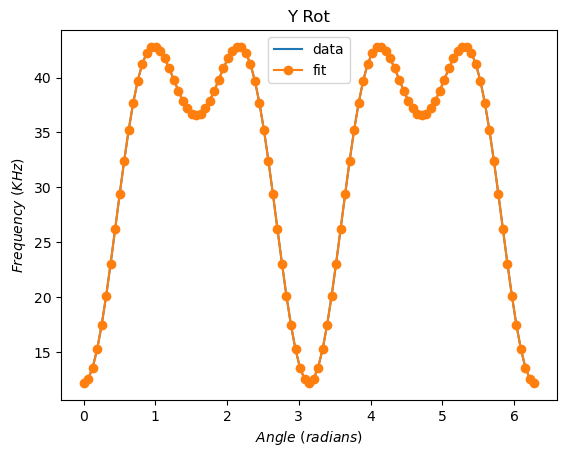

In [46]:
# Reading Data
# xdata = np.linspace(-np.pi, np.pi)
# ydata = np.zeros_like(xdata)
# ydata[xdata > 0] = 1

xdata = x_float
ydata = fy_float

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('Y Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()